# Cross-Sectional Mean Reversion Signal — Research Notebook

End-to-end research pipeline for a **cross-sectional mean-reversion** signal on crypto OHLCV data.
The core hypothesis: assets that have moved furthest (in absolute or vol-adjusted terms) relative to their peers or their own history will tend to revert over short holding horizons.

| Section | Topic |
|---------|-------|
| §1 | Setup — project root, imports, display options |
| §2 | Configuration — load `configs/research/mean_reversion_signal.yaml` + DB engine |
| §3 | Data — load universe & OHLCV panel |
| §4 | Signal Pipeline — build signal & all feature panels |
| §5 | IC Analysis — per-feature IC / t-stat across all feature families |
| §6 | Diagnostics — IC distribution, rolling IC, coverage, quantiles |
| §7 | Backtest — long/short PnL, cost stress, legs, benchmark correlation |
| §8 | Execution & Events — rolling Sharpe, execution delay, vol-regime conditioning |
| §9 | Robustness — lookback × holding × transform × universe grid; train/test IC |
| §10 | Interpretation — checklist & summary |

All timestamps are **UTC**; run cells top to bottom (later sections reuse panels built earlier).

**Dependencies:** `cs_mean_reversion`, `cs_momentum`, `momentum_eval`, `panel_io`, `research_config`; a populated Postgres DB (OHLCV + universe tables).

## Summary — Key Findings

**Signal studied:** short-term cross-sectional reversal on an hourly crypto universe; the standout feature was a **1-bar return reversal** (`reversal_h1`).

- **The reversal effect is statistically real.** Mean IC **0.081** with a Newey-West t-stat of **30.4** — and unlike the momentum sleeve, this survives selection correction: the max-over-trials p-value is ≈ 0 whether trials are counted as 9 feature families or all 77 scans (§9). It is cleanly market-neutral (correlation to XBT/USD ≈ 0.03) and it is **not a stale-print artifact**: masking forward-filled bars moves the IC by ≤ 0.0001, because the monthly liquidity filter already excludes the thin names (§5).
- **It decays but persists out of sample.** Walk-forward IC across five embargoed folds: 0.094 → 0.074 → 0.077 → 0.068 → 0.041, all significant; the honest select-on-past/score-on-next-fold grid evaluation pools to an out-of-sample IC of **0.071 (NW t ≈ 21)** (§9).
- **Same-print leakage is now measured, not assumed.** Fills use real 1-minute prints at close-time + δ — LOCF-carried (stale) fills are excluded, so every priced period trades at prints that actually happened. Moving from δ = 0 (filling at the very print that formed the signal) to δ = 1 minute costs ≈ **2.4 Sharpe**, and the delay curve decays out to δ = 60 min (§7–8).
- **But the gross edge is inside the bid-ask bounce floor.** Corwin–Schultz effective half-spreads (hourly ranges, stale bars excluded) run ≈ **8–15 bps** across the universe (XBT/USD ≈ 10 bps as a full-period average). The gross edge of ≈ 7.1 bps per period is only **0.33×** the bounce floor (turnover × mean half-spread ≈ 21 bps) — consistent with harvesting the bounce of others' prints, which a taker gives straight back on entry (§7).
- **And costs are terminal at this horizon.** Turnover annualises to ~6,500×; at 40 bps fees the +3.7 gross Sharpe is **−27.5 net** with the flat 1 bp spread assumption and **−37.8** with per-asset spreads. Break-even costs are ~7 bps round-trip — not available to a taker on spot.
- **Takeaway / next steps:** a genuine, slowly decaying cross-sectional reversal whose gross P&L at hourly horizons is mostly bid-ask bounce and whose net P&L is destroyed by spot taker costs. The constructive paths are **maker-side execution or perpetual futures** (2–5 bps taker fees, real shorts, funding data), and **lower-turnover construction** — slower dislocation windows (the 4–6 h reversals retain IC ≈ 0.06), hysteresis bands, and longer holds — trading gross Sharpe for a positive net.


## §1 Setup

Locate the project root (`src/` + `configs/`), add it to `sys.path`, and import the mean-reversion signal builders and `momentum_eval` evaluation helpers.

In [1]:
from pathlib import Path
import os
import sys
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common.db import make_engine
from src.common.research_config import load_research_settings
from src.data.panel_io import (
    fetch_minute_exec_closes,
    fetch_ohlcv_long,
    list_universe_symbols,
)

# Minute-level execution modelling (entry/exit at signal close + delta minutes)
from src.research.execution import (
    build_execution_close_panel,
    compute_execution_forward_returns,
)
from src.research.spreads import estimate_half_spread_bps_from_long

# Mean-reversion feature builders
from src.signals.cs_mean_reversion import (
    build_mean_reversion_signal,
    build_return_reversal_features,
    build_price_zscore_features,
    build_vol_adjusted_move,
    build_extreme_move_indicator,
    build_volume_exhaustion_features,
    build_vwap_distance_features,
    build_rsi_proxy,
    build_range_position,
    build_xsec_rank_of_price_z,
)

# Momentum feature builders (useful as comparators — momentum and reversal are
# complementary; the same evaluation helpers work for both)
from src.signals.cs_momentum import (
    build_feature_panels as build_momentum_feature_panels,
    build_monthly_universe_mask,
    compute_forward_returns,
    cross_sectional_rank_or_zscore,
    apply_rebalance_decimation,
    apply_traded_mask,
    build_traded_mask,
)

# Evaluation helpers (fully reusable from momentum research)
from src.research.momentum_eval import (
    compute_ic_series,
    ic_summary,
    rolling_mean,
    rolling_sharpe,
    run_light_backtest,
    quantile_analysis,
    long_short_leg_returns,
    market_correlation,
    max_drawdown,
    compute_ic_decay_heatmap,
    plot_ic_decay_heatmap,
    max_over_trials_pvalue,
    deflated_sharpe_ratio,
    walk_forward_ic_table,
    walk_forward_selection,
)

pd.options.display.float_format = "{:.4f}".format
# Silence pandas FutureWarnings from downstream resample/ffill calls so the
# notebook output stays readable; revisit when the project pins a newer pandas.
warnings.filterwarnings("ignore", category=FutureWarning)

## §2 Configuration

Load research parameters from `configs/research/mean_reversion_signal.yaml` and open the DB engine. Key knobs: signal timeframe, reversal lookback, vol/VWAP/RSI/range window lengths, cross-sectional transform, fee/spread assumptions, and the train/test split date. Feature horizons here are shorter than in the momentum config — mean reversion operates on 4h–24h windows, not days/weeks.

In [2]:
settings = load_research_settings("configs/research/mean_reversion_signal.yaml")
engine = make_engine(settings)

settings_preview_keys = [
    "signal_timeframe",
    "reversal_lookback_bars",
    "holding_period_bars",
    "execution_delay_bars",
    "ic_rebalance_bars",
    "use_minute_execution",
    "execution_delay_minutes",
    "execution_delay_minutes_grid",
    "log_returns",
    "price_zscore_window_bars",
    "bollinger_window_bars",
    "vol_window_bars",
    "vwap_window_bars",
    "volume_window_bars",
    "rsi_window_bars",
    "range_position_window_bars",
    "extreme_move_threshold_sigma",
    "feature_horizons_bars",
    "cross_sectional_transform",
    "benchmark_symbol",
    "data_start_date",
    "data_end_date",
    "train_split_date",
    "max_assets",
    "top_quantile",
    "bottom_quantile",
    "fee_bps",
    "half_spread_bps",
]

{k: settings[k] for k in settings_preview_keys}

{'signal_timeframe': '1h',
 'reversal_lookback_bars': 2,
 'holding_period_bars': 2,
 'execution_delay_bars': 0,
 'ic_rebalance_bars': 2,
 'use_minute_execution': True,
 'execution_delay_minutes': 1,
 'execution_delay_minutes_grid': [0, 1, 5, 15, 30, 60],
 'log_returns': True,
 'price_zscore_window_bars': 24,
 'bollinger_window_bars': 20,
 'vol_window_bars': 14,
 'vwap_window_bars': 24,
 'volume_window_bars': 24,
 'rsi_window_bars': 14,
 'range_position_window_bars': 12,
 'extreme_move_threshold_sigma': 2.0,
 'feature_horizons_bars': [1, 2, 4, 6],
 'cross_sectional_transform': 'rank',
 'benchmark_symbol': 'XBT/USD',
 'data_start_date': Timestamp('2020-09-30 23:59:59+0000', tz='UTC'),
 'data_end_date': Timestamp('2024-06-30 23:59:59+0000', tz='UTC'),
 'train_split_date': Timestamp('2022-06-30 23:59:59+0000', tz='UTC'),
 'max_assets': 20,
 'top_quantile': 0.2,
 'bottom_quantile': 0.2,
 'fee_bps': 40.0,
 'half_spread_bps': 1.0}

## §3 Data

Pull the **monthly rebalance universe** (rank-filtered liquid names) and long-format OHLCV for the research date range. This is the only cell that hits the database; all downstream sections work in-memory on `df_long`. Mean-reversion features also require **volume** (for VWAP and volume-exhaustion features), so `volume_wide` is retained alongside `close_wide`.

In [3]:
# Optionally restrict to monthly universe members.
if settings.get("use_monthly_universe", True):
    universe_df = list_universe_symbols(
        engine,
        as_of_date=None,
        top_n=settings.get("max_assets"),
    )
    universe_df["rebalance_date"] = pd.to_datetime(universe_df["rebalance_date"], utc=True)
    universe_df = universe_df[
        (universe_df["rebalance_date"] >= settings["data_start_date"].normalize())
        & (universe_df["rebalance_date"] <= settings["data_end_date"].normalize())
    ]
    symbols = sorted(universe_df["symbol"].unique().tolist())
    print(f"Universe snapshots loaded: {len(universe_df)} rows, "
          f"{universe_df['rebalance_date'].nunique()} months")
else:
    universe_df = None
    symbols = None

df_long = fetch_ohlcv_long(
    engine,
    start_ts=settings["data_start_date"],
    end_ts=settings["data_end_date"],
    symbols=symbols,
)

print(f"\nRaw OHLCV rows : {len(df_long):,}")
print(f"Symbols        : {df_long['symbol'].nunique()}")
print(f"Date range     : {df_long['ts'].min()} -> {df_long['ts'].max()}")
print(f"Monthly points : {0 if universe_df is None else universe_df['rebalance_date'].nunique()}")
df_long.head(3)

Universe snapshots loaded: 669 rows, 43 months



Raw OHLCV rows : 1,704,347
Symbols        : 64
Date range     : 2020-10-01 00:00:00+00:00 -> 2024-06-30 23:00:00+00:00
Monthly points : 43


,ts,symbol,open,high,low,close,volume,trades,dollar_volume
0,2020-10-01 00:00:00+00:00,ADA/USD,0.1015,0.1030,0.1013,0.1025,560347.3378,76,57428.3176
1,2020-10-01 00:00:00+00:00,ALGO/USD,0.3467,0.3482,0.3440,0.3463,27848.4159,31,9645.2989
2,2020-10-01 00:00:00+00:00,ATOM/USD,5.3753,5.4484,5.3753,5.4233,520.9104,19,2825.0531


## §4 Signal Pipeline

Build the core mean-reversion signal and **all feature panels** in one pass.  Feature families:

| Family | Builder | Core idea |
|--------|---------|----------|
| Return Reversal | `build_return_reversal_features` | Negate short-term returns |
| Price Z-Score / Bollinger | `build_price_zscore_features` | Distance from rolling mean |
| Vol-Adjusted Move | `build_vol_adjusted_move` | Return scaled by trailing vol |
| Extreme Move | `build_extreme_move_indicator` | Identify outsized single-bar moves |
| Volume Exhaustion | `build_volume_exhaustion_features` | Move size conditioned on volume |
| VWAP Distance | `build_vwap_distance_features` | Distance from rolling VWAP / MA |
| RSI Proxy | `build_rsi_proxy` | Overbought/oversold |
| Range Position (%K) | `build_range_position` | Position within recent high-low range |
| XSec Rank of Price-Z | `build_xsec_rank_of_price_z` | Relative stretch vs peers |

Momentum feature panels are also computed as a benchmark comparison.

In [4]:
# --- Core pipeline -----------------------------------------------------------
pipeline = build_mean_reversion_signal(
    df_long,
    signal_timeframe=settings["signal_timeframe"],
    reversal_lookback_bars=settings["reversal_lookback_bars"],
    universe_df=universe_df,
    cross_sectional_transform=settings["cross_sectional_transform"],
    min_assets_per_timestamp=settings["min_assets_per_timestamp"],
    log_returns=settings["log_returns"],
    ic_rebalance_bars=settings["ic_rebalance_bars"],
)

close_wide    = pipeline["close_wide"]
volume_wide   = pipeline["volume_wide"]
return_wide   = pipeline["return_wide"]
signal        = pipeline["signal"]
signal_fresh  = pipeline["signal_fresh"]
universe_mask = pipeline["universe_mask"]

# --- Forward returns ---------------------------------------------------------
fwd_ret = compute_forward_returns(
    close_wide,
    holding_period_bars=settings["holding_period_bars"],
    log_returns=settings["log_returns"],
)

# Universe-masked panels keep IC diagnostics aligned to the tradable universe.
def _mask_to_universe(panel):
    if universe_mask is None:
        return panel
    aligned_mask = universe_mask.reindex(index=panel.index, columns=panel.columns).fillna(False)
    return panel.where(aligned_mask)

xsec_universe_fwd_ret = _mask_to_universe(fwd_ret)
analysis_fwd_ret = xsec_universe_fwd_ret

horizons = settings["feature_horizons_bars"]

# --- Mean-reversion feature panels ------------------------------------------
feat_reversal   = build_return_reversal_features(
    close_wide, horizons, log_returns=settings["log_returns"],
    universe_mask=universe_mask,
)
feat_price_z    = build_price_zscore_features(
    close_wide,
    price_zscore_window_bars=settings["price_zscore_window_bars"],
    bollinger_window_bars=settings["bollinger_window_bars"],
)
feat_vol_adj    = build_vol_adjusted_move(
    close_wide, horizons,
    vol_window_bars=settings["vol_window_bars"],
    log_returns=settings["log_returns"],
)
feat_extreme    = build_extreme_move_indicator(
    close_wide,
    vol_window_bars=settings["vol_window_bars"],
    threshold_sigma=settings["extreme_move_threshold_sigma"],
    log_returns=settings["log_returns"],
)
feat_vol_exh    = build_volume_exhaustion_features(
    close_wide, volume_wide, horizons,
    volume_window_bars=settings["volume_window_bars"],
    log_returns=settings["log_returns"],
)
feat_vwap       = build_vwap_distance_features(
    close_wide, volume_wide,
    vwap_window_bars=settings["vwap_window_bars"],
    ma_window_bars=settings["vwap_window_bars"],
)
feat_rsi        = build_rsi_proxy(
    close_wide,
    rsi_window_bars=settings["rsi_window_bars"],
    log_returns=settings["log_returns"],
)
feat_range      = build_range_position(
    close_wide,
    range_window_bars=settings["range_position_window_bars"],
)
feat_xsec_z     = build_xsec_rank_of_price_z(
    close_wide,
    price_zscore_window_bars=settings["price_zscore_window_bars"],
    min_assets_per_timestamp=settings["min_assets_per_timestamp"],
)

# --- Momentum feature panels (for comparison) --------------------------------
mom_feat_panels = build_momentum_feature_panels(
    close_wide,
    horizons=horizons,
    benchmark_symbol=settings["benchmark_symbol"],
    vol_window_bars=settings["vol_window_bars"],
    log_returns=settings["log_returns"],
    universe_mask=universe_mask,
)

print("Panel shapes summary:")
print(f"  close_wide  : {close_wide.shape}")
print(f"  volume_wide : {volume_wide.shape}")
print(f"  fwd_ret     : {fwd_ret.shape}")
print(f"  signal      : {signal.shape}")
print(f"  horizons    : {horizons}")

Panel shapes summary:
  close_wide  : (32856, 64)
  volume_wide : (32856, 64)
  fwd_ret     : (32856, 64)
  signal      : (32856, 64)
  horizons    : [1, 2, 4, 6]


## §5 IC Analysis

Raw short-term returns should show *negative* mean IC (recent winners underperform) — this confirms the reversal hypothesis. After negation, all mean-reversion feature builders return already-negated values, so positive IC is expected throughout the comparison table.

Newey-West lag accounts for overlapping forward returns, lookback windows, and rebalance decimation.

In [5]:
# --- Feature family comparison table ----------------------------------------
# Each row is one (feature_name, horizon) combo.
# Features without a horizon dimension appear once.
# Horizon-aware features pass their own lookback in `lookback_bars` so the
# NW lag absorbs that overlap exactly. Non-horizon features default to the
# headline `nw` (built from R, H, D above).

records = []

H   = settings["holding_period_bars"]
R   = settings["reversal_lookback_bars"]
D   = settings["ic_rebalance_bars"]
min_assets = settings["min_assets_per_timestamp"]
# IC series observations are D bars apart in real time after subsampling.
# The NW lag is expressed in units of the subsampled series: last lag L where
# L*D < max(H, R), i.e. (max(H, R) - 1) // D.
# We have not resampled these signals yet, they are raw so nw = (max(H, R) - 1)

def _add(name, panel, lookback_bars=None):
    panel_u = _mask_to_universe(panel)
    ic = compute_ic_series(panel_u, analysis_fwd_ret, min_assets=min_assets)
    local_lookback = R if lookback_bars is None else int(lookback_bars)
    local_nw = (max(H, local_lookback) - 1)
    row = ic_summary(ic, nw_lag=local_nw)
    row["feature"] = name
    records.append(row)

# Return reversal
for h in horizons:
    _add(f"reversal_h{h}",       feat_reversal[h]["reversal"],      lookback_bars=h)
    _add(f"xsec_reversal_h{h}",  feat_reversal[h]["xsec_reversal"], lookback_bars=h)

# Price z-score / Bollinger band-touch
_add("price_zscore",     feat_price_z["price_zscore"],
     lookback_bars=settings["price_zscore_window_bars"])
_add("bollinger_touch",  feat_price_z["bollinger_touch"],
     lookback_bars=settings["bollinger_window_bars"])

# Vol-adjusted move
for h in horizons:
    _add(f"vol_adj_reversal_h{h}",      feat_vol_adj[h]["vol_adj_reversal"],      lookback_bars=h)
    _add(f"vol_adj_xsec_reversal_h{h}", feat_vol_adj[h]["vol_adj_xsec_reversal"], lookback_bars=h)

# Extreme move (single-bar z-score → lookback is 1, vol estimation window is separate)
_add("extreme_signed_z", feat_extreme["signed_z"],     lookback_bars=1)
_add("extreme_flag",     feat_extreme["extreme_flag"], lookback_bars=1)

# Volume exhaustion
for h in horizons:
    _add(f"vol_exhaustion_h{h}", feat_vol_exh[h]["vol_exhaustion"], lookback_bars=h)
    _add(f"vol_blowoff_h{h}",    feat_vol_exh[h]["vol_blowoff"],    lookback_bars=h)

# VWAP / MA distance (single-bar deviation from rolling anchor)
_add("distance_from_vwap", feat_vwap["distance_from_vwap"], lookback_bars=1)
_add("distance_from_ma",   feat_vwap["distance_from_ma"],   lookback_bars=1)

# RSI proxy
_add("rsi_proxy",          feat_rsi["rsi_proxy"],
     lookback_bars=settings["rsi_window_bars"])

# Range position
_add("range_position",     feat_range["range_position"],
     lookback_bars=settings["range_position_window_bars"])

# XSec rank of price z
_add("xsec_rank_price_z",  feat_xsec_z["xsec_rank_price_z"],
     lookback_bars=settings["price_zscore_window_bars"])

# Momentum features (for comparison — expect lower/opposite IC)
for h, ret_wide in mom_feat_panels["core_returns"].items():
    _add(f"momentum_core_h{h}",         ret_wide,                       lookback_bars=h)
for h, rel in mom_feat_panels["relative_features"].items():
    _add(f"momentum_xsec_mean_h{h}",    rel["minus_xsec_mean"],         lookback_bars=h)
for h, va in mom_feat_panels["vol_adjusted_features"].items():
    _add(f"momentum_return_over_vol_h{h}", va["return_over_vol"],       lookback_bars=h)

ic_table = (
    pd.DataFrame(records)
    .set_index("feature")
    [["mean_ic", "median_ic", "std_ic", "t_stat_ic_nw", "n_obs", "nw_lag"]]
    .sort_values("t_stat_ic_nw", ascending=False)
)

print("=== Feature IC Comparison (sorted by NW t-stat) ===")
print(ic_table.to_string())

# Identify best mean-reversion feature for downstream analysis.
mr_features_mask = ~ic_table.index.str.startswith("momentum_")
best_mr_feature_name = ic_table.loc[mr_features_mask]["t_stat_ic_nw"].idxmax()
print(f"\nBest mean-reversion feature: {best_mr_feature_name}")

=== Feature IC Comparison (sorted by NW t-stat) ===
                             mean_ic  median_ic  std_ic  t_stat_ic_nw  n_obs  nw_lag
feature                                                                             
reversal_h1                   0.0698     0.0737  0.3254       37.8614  29880       1
xsec_reversal_h1              0.0698     0.0737  0.3254       37.8614  29880       1
reversal_h2                   0.0705     0.0769  0.3263       34.4963  29884       1
xsec_reversal_h2              0.0705     0.0769  0.3263       34.4963  29884       1
vol_adj_xsec_reversal_h1      0.0554     0.0596  0.3055       31.5063  29880       1
vol_adj_reversal_h1           0.0554     0.0596  0.3055       31.5063  29880       1
vol_blowoff_h1                0.0555     0.0586  0.3094       31.4014  29880       1
vol_exhaustion_h1             0.0528     0.0559  0.3050       30.3925  29880       1
reversal_h4                   0.0653     0.0707  0.3298       29.1521  29887       3
xsec_reversal

### Stale-Print Contribution — Traded-Bar Mask

The hourly loader forward-fills no-trade hours (`trades = 0`), so some closes are stale copies of an older print. Stale prints mechanically **inflate** measured reversal: an asset with a stale bar shows a 0% return while peers move, ranks as a cross-sectional "loser", then "reverts" when its next real trade catches up (non-synchronous trading, Lo–MacKinlay 1990). The minute-execution panel has the same exposure through its LOCF fallbacks on illiquid names.

The table below recomputes the headline features' IC requiring **both feature endpoints** (`t`, `t−h`) and **both forward-return endpoints** (`t`, `t+H`) to be real prints. The masked column is the honest estimate of the reversal effect; the delta is the stale-print artifact.


In [6]:
# --- Traded-bar mask: how much of the reversal IC is stale prints? -----------
traded_mask = build_traded_mask(df_long, settings["signal_timeframe"])

# Prevalence: share of in-universe, priced cells whose bar had no real trade.
_univ_cells = close_wide.notna()
if universe_mask is not None:
    _univ_cells &= universe_mask.reindex(
        index=close_wide.index, columns=close_wide.columns, fill_value=False
    ).astype(bool)
_aligned_traded = traded_mask.reindex(
    index=close_wide.index, columns=close_wide.columns, fill_value=False
).astype(bool)
stale_share = float((_univ_cells & ~_aligned_traded).sum().sum() / _univ_cells.sum().sum())
print(f"Stale (no-trade) share of in-universe bars: {stale_share:.2%}")

fwd_ret_traded = apply_traded_mask(analysis_fwd_ret, traded_mask, forward_bars=H)

mask_rows = []
_mask_candidates = [(f"reversal_h{h}", feat_reversal[h]["reversal"], h) for h in horizons]
_mask_candidates += [
    ("extreme_signed_z",   feat_extreme["signed_z"],        1),
    ("distance_from_vwap", feat_vwap["distance_from_vwap"], 1),
]
for _name, _panel, _lb in _mask_candidates:
    _panel_u = _mask_to_universe(_panel)
    _nw_loc = max(H, _lb) - 1
    _s_all = ic_summary(
        compute_ic_series(_panel_u, analysis_fwd_ret, min_assets=min_assets),
        nw_lag=_nw_loc,
    )
    _s_msk = ic_summary(
        compute_ic_series(
            apply_traded_mask(_panel_u, traded_mask, lookback_bars=_lb),
            fwd_ret_traded,
            min_assets=min_assets,
        ),
        nw_lag=_nw_loc,
    )
    mask_rows.append({
        "feature": _name,
        "mean_ic_all": _s_all["mean_ic"],
        "mean_ic_traded_only": _s_msk["mean_ic"],
        "stale_artifact": _s_all["mean_ic"] - _s_msk["mean_ic"],
        "t_nw_all": _s_all["t_stat_ic_nw"],
        "t_nw_traded_only": _s_msk["t_stat_ic_nw"],
        "n_obs_traded_only": _s_msk["n_obs"],
    })

stale_ic_table = pd.DataFrame(mask_rows).set_index("feature")
print("\n=== Reversal IC: all bars vs real-print bars only ===")
print(stale_ic_table.to_string())
_worst_name = stale_ic_table["stale_artifact"].idxmax()
_worst = float(stale_ic_table.loc[_worst_name, "stale_artifact"])
print(f"\nLargest stale-print artifact: {_worst:+.4f} IC on {_worst_name} "
      f"({_worst / stale_ic_table.loc[_worst_name, 'mean_ic_all']:.0%} of its unmasked IC)")


Stale (no-trade) share of in-universe bars: 0.11%



=== Reversal IC: all bars vs real-print bars only ===
                    mean_ic_all  mean_ic_traded_only  stale_artifact  t_nw_all  t_nw_traded_only  n_obs_traded_only
feature                                                                                                            
reversal_h1              0.0698               0.0698          0.0000   37.8614           37.8536              29864
reversal_h2              0.0705               0.0704          0.0001   34.4963           34.4104              29860
reversal_h4              0.0653               0.0652          0.0001   29.1521           29.0811              29853
reversal_h6              0.0616               0.0615          0.0001   26.6330           26.5489              29851
extreme_signed_z         0.0480               0.0479          0.0000   27.2142           27.1975              29864
distance_from_vwap       0.0558               0.0557          0.0001   25.1314           25.0780              29864

Largest stale-pr

### IC Decay Heatmap — Signal × Holding Period

This heatmap sweeps candidate mean-reversion signals across a grid of holding periods and reports the Newey-West-adjusted IC t-stat for each. For mean reversion the expectation is a steep decay: t-stats should peak at *h = 1* (one 1h bar) and fall away quickly, confirming the edge is short-lived and execution-sensitive. A signal that stays significant well beyond *h = 24* shows unexpected persistence and may be capturing a momentum effect rather than genuine reversion.

**Newey-West lag.** Overlapping windows induce serial correlation in the IC series, so the iid t-stat is too optimistic. Two IC observations stay correlated as long as they share *either* forward-return data (up to `H − 1` bars apart) *or* signal-lookback data (up to `R − 1` bars apart), so the binding truncation lag is `max(H, R) − 1` — the *larger* of the two overlaps, not their sum. Using `nw_lag = 0` would understate the standard error and inflate the t-stat at longer horizons.

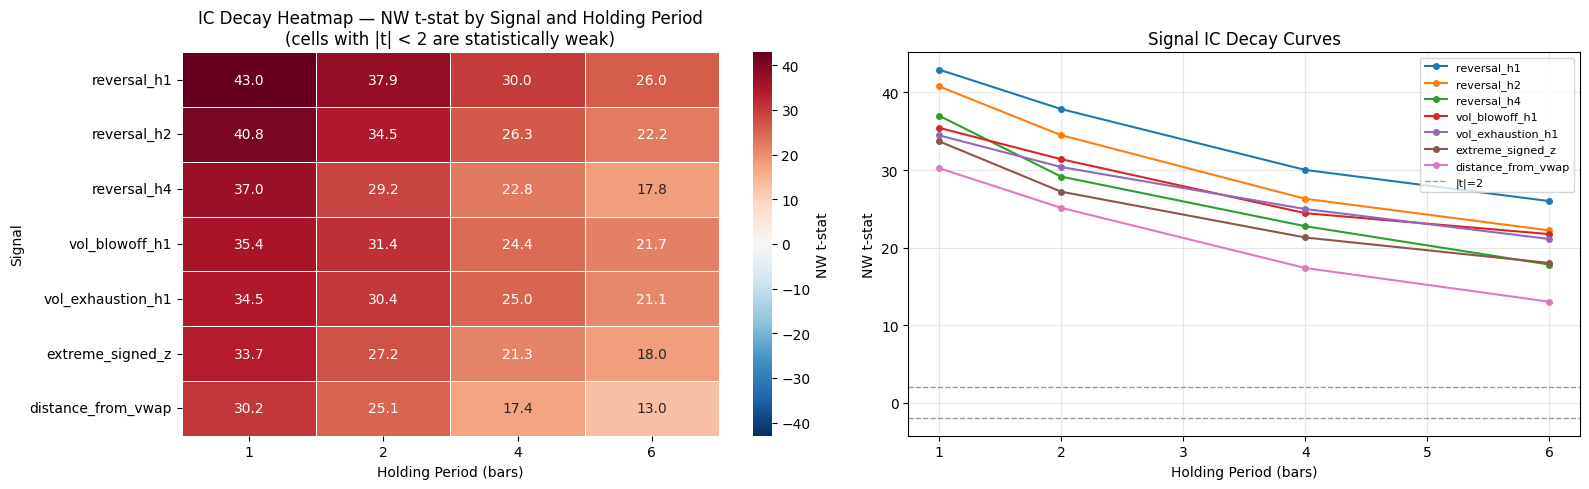

Signal                    | Peak hold |   Peak t |  t @ h=1 | Zero-cross hold
------------------------------------------------------------------------
reversal_h1               |         1 |    42.95 |    42.95 | >max (6)
reversal_h2               |         1 |    40.79 |    40.79 | >max (6)
reversal_h4               |         1 |    37.01 |    37.01 | >max (6)
vol_blowoff_h1            |         1 |    35.44 |    35.44 | >max (6)
vol_exhaustion_h1         |         1 |    34.48 |    34.48 | >max (6)
extreme_signed_z          |         1 |    33.71 |    33.71 | >max (6)
distance_from_vwap        |         1 |    30.24 |    30.24 | >max (6)


In [7]:
holding_period_grid = [1, 2, 4, 6]

# Raw and xsec variants of the same underlying are highly correlated — pick one.
# Adjust if the IC table above suggests a different top-5.
candidate_signals_raw = {
    "reversal_h1":        feat_reversal[1]["reversal"],
    "reversal_h2":        feat_reversal[2]["reversal"],
    "reversal_h4":        feat_reversal[4]["reversal"],
    "vol_blowoff_h1":     feat_vol_exh[1]["vol_blowoff"],
    "vol_exhaustion_h1":  feat_vol_exh[1]["vol_exhaustion"],
    "extreme_signed_z":   feat_extreme["signed_z"],
    "distance_from_vwap": feat_vwap["distance_from_vwap"],
}
candidate_signals = {k: _mask_to_universe(v) for k, v in candidate_signals_raw.items()}

# Feature lookback for each signal — drives NW lag = max(feature_horizon, h) - 1.
# All candidates here use a 1-bar lookback (matching lookback_bars=1 in the IC table above).
feature_horizons = {
    "reversal_h1":        1,
    "reversal_h2":        2,
    "reversal_h4":        4,
    "vol_blowoff_h1":     1,
    "vol_exhaustion_h1":  1,
    "extreme_signed_z":   1,
    "distance_from_vwap": 1,
}

t_stat_heatmap, mean_ic_heatmap = compute_ic_decay_heatmap(
    candidate_signals=candidate_signals,
    close_wide=close_wide,
    holding_period_grid=holding_period_grid,
    log_returns=settings["log_returns"],
    min_assets=settings["min_assets_per_timestamp"],
    feature_horizons=feature_horizons,
)

plot_ic_decay_heatmap(t_stat_heatmap)

In [8]:
# ---- Select signal and holding period based on IC decay heatmap above -------
selected_feature_name           = 'reversal_h1'
apply_xsec_transform            = True
apply_rebalance_decimation_flag = True

# Single trading-cadence knob: the backtest rebalances every
# `selected_holding_period` bars on a fresh signal and holds those H bars.
# Decimation via ic_rebalance_bars is an IC-analysis device only and no
# longer feeds the backtest. (Previously this was hard-coded to 1 while the
# signal was decimated every 2 bars — two mixed cadence mechanisms.)
selected_holding_period = int(settings["holding_period_bars"])

fwd_ret = compute_forward_returns(
    close_wide, holding_period_bars=selected_holding_period, log_returns=settings["log_returns"]
)
analysis_fwd_ret = _mask_to_universe(fwd_ret)

def _parse_lookback(name: str) -> int:
    m = re.search(r"_h(\d+)$", name)
    if m:
        return int(m.group(1))
    _fixed = {
        "price_zscore":    "price_zscore_window_bars",
        "bollinger":       "bollinger_window_bars",
        "rsi":             "rsi_window_bars",
        "range":           "range_position_window_bars",
        "xsec_rank_price_z": "price_zscore_window_bars",
    }
    for frag, key in _fixed.items():
        if frag in name:
            return int(settings[key])
    return int(settings["reversal_lookback_bars"])

selected_lookback = _parse_lookback(selected_feature_name)

def _get_feature_panel(name: str):
    m = re.search(r"_h(\d+)$", name)
    h = int(m.group(1)) if m else None
    if name.startswith("reversal_h"):              return feat_reversal[h]["reversal"]
    if name.startswith("xsec_reversal_h"):         return feat_reversal[h]["xsec_reversal"]
    if name.startswith("vol_adj_xsec_reversal_h"): return feat_vol_adj[h]["vol_adj_xsec_reversal"]
    if name.startswith("vol_adj_reversal_h"):      return feat_vol_adj[h]["vol_adj_reversal"]
    if name.startswith("vol_exhaustion_h"):        return feat_vol_exh[h]["vol_exhaustion"]
    if name.startswith("vol_blowoff_h"):           return feat_vol_exh[h]["vol_blowoff"]
    if name == "price_zscore":       return feat_price_z["price_zscore"]
    if name == "bollinger_touch":    return feat_price_z["bollinger_touch"]
    if name == "extreme_signed_z":   return feat_extreme["signed_z"]
    if name == "extreme_flag":       return feat_extreme["extreme_flag"]
    if name == "distance_from_vwap": return feat_vwap["distance_from_vwap"]
    if name == "distance_from_ma":   return feat_vwap["distance_from_ma"]
    if name == "rsi_proxy":          return feat_rsi["rsi_proxy"]
    if name == "range_position":     return feat_range["range_position"]
    if name == "xsec_rank_price_z":  return feat_xsec_z["xsec_rank_price_z"]
    raise ValueError(f"Unknown feature: {name!r}")

raw_panel = _mask_to_universe(_get_feature_panel(selected_feature_name))

if apply_xsec_transform:
    selected_signal_fresh = cross_sectional_rank_or_zscore(
        raw_panel,
        method=settings["cross_sectional_transform"],
        min_assets_per_timestamp=settings["min_assets_per_timestamp"],
    )
else:
    selected_signal_fresh = raw_panel

# Decimated copy for IC analysis only ("what does the held signal
# predict?"). All backtests below consume selected_signal_fresh.
if apply_rebalance_decimation_flag and D > 1:
    selected_signal = apply_rebalance_decimation(selected_signal_fresh, every_n_bars=D)
else:
    selected_signal = selected_signal_fresh

selected_signal_label = selected_feature_name
print(f"Selected signal         : {selected_signal_label}")
print(f"Selected holding period : {selected_holding_period} bars")
print(f"Lookback                : {selected_lookback} bars")
print(f"Signal shape            : {selected_signal.shape}")
_delay_desc = (
    f"{settings['execution_delay_minutes']} min (real 1m fills)"
    if settings["use_minute_execution"]
    else f"{settings['execution_delay_bars']} signal bars"
)
print(f"Execution timeline      : signal at bar t is known at close(t); "
      f"fills at close(t) + {_delay_desc}")

nw  = (max(selected_holding_period, selected_lookback) - 1) // D if (apply_rebalance_decimation_flag and D > 1) else (max(selected_holding_period, selected_lookback) - 1)

signal_for_ic  = selected_signal.iloc[::D] if (apply_rebalance_decimation_flag and D > 1) else selected_signal
fwd_ret_for_ic = analysis_fwd_ret.reindex(signal_for_ic.index)
ic_series = compute_ic_series(signal_for_ic, fwd_ret_for_ic, min_assets=min_assets)
summary_signal = ic_summary(ic_series, nw_lag=nw)

coverage = signal_for_ic.notna().sum(axis=1)
turnover_proxy = 0.5 * signal_for_ic.fillna(0.0).diff().abs().sum(axis=1)

summary = {
    **summary_signal,
    "selected_holding_period": selected_holding_period,
    "avg_assets_per_ts": float(coverage.mean()),
    "avg_turnover_proxy": float(turnover_proxy.mean(skipna=True)),
}

summary

Selected signal         : reversal_h1
Selected holding period : 2 bars
Lookback                : 1 bars
Signal shape            : (32856, 64)
Execution timeline      : signal at bar t is known at close(t); fills at close(t) + 1 min (real 1m fills)


{'n_obs': 14939,
 'mean_ic': 0.07080131438661448,
 'median_ic': 0.07518796992481201,
 'std_ic': 0.3266297778442807,
 't_stat_ic': 26.493925351024433,
 't_stat_ic_nw': 26.493925351024433,
 'nw_lag': 0,
 'p05_ic': -0.4821992481203006,
 'p95_ic': 0.6075187969924812,
 'selected_holding_period': 2,
 'avg_assets_per_ts': 14.37399561723886,
 'avg_turnover_proxy': 2.368481554285305}

## §6 Diagnostics

Visual and tabular checks on the **selected signal**:

- IC histogram and time series with rolling mean
- Universe coverage (when asset count drops below `min_assets_per_timestamp`, the strategy is flat)
- Quantile portfolio forward returns and monotonicity correlation

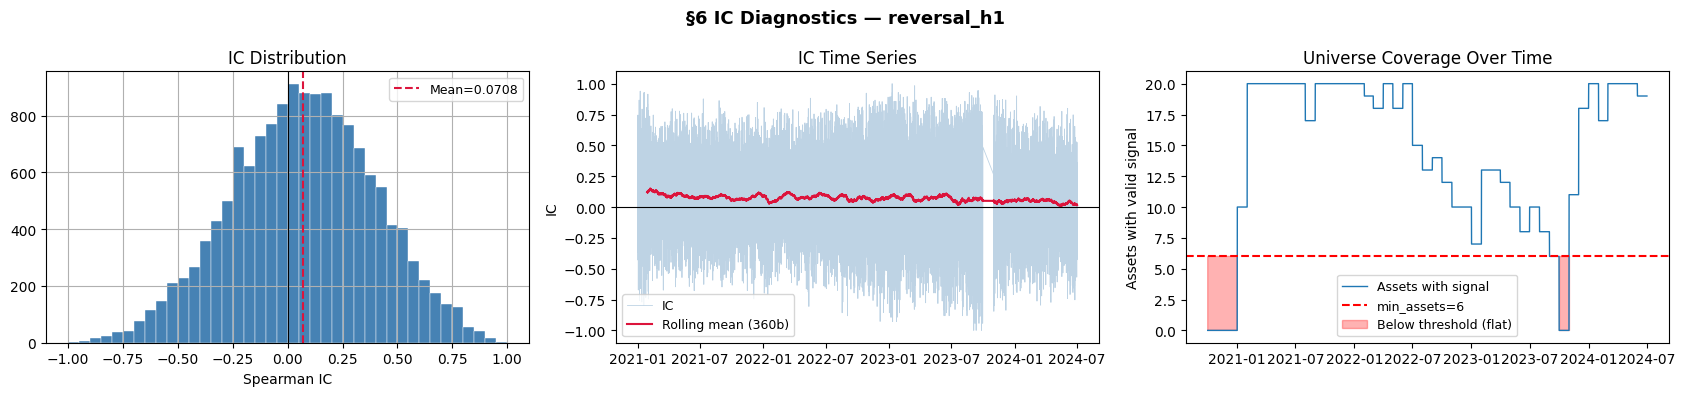

IC summary: mean=0.0708, std=0.3266, NW t-stat=26.49


In [9]:
rolling_ic = rolling_mean(ic_series, window=settings["rolling_window_bars"])

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle(f"\u00a76 IC Diagnostics \u2014 {selected_signal_label}", fontsize=13, fontweight="bold")

# IC histogram
ax = axes[0]
ic_series.dropna().hist(bins=40, ax=ax, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(ic_series.mean(), color="crimson", linestyle="--", label=f"Mean={ic_series.mean():.4f}")
ax.axvline(0, color="black", linestyle="-", linewidth=0.8)
ax.set_title("IC Distribution")
ax.set_xlabel("Spearman IC")
ax.legend(fontsize=9)

# IC time series + rolling mean
ax = axes[1]
ax.plot(ic_series.index, ic_series.values, alpha=0.35, color="steelblue", linewidth=0.6, label="IC")
ax.plot(rolling_ic.index, rolling_ic.values, color="crimson", linewidth=1.5,
        label=f"Rolling mean ({settings['rolling_window_bars']}b)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("IC Time Series")
ax.set_ylabel("IC")
ax.legend(fontsize=9)

# Coverage with min_assets threshold (matching momentum notebook style)
ax = axes[2]
coverage = signal_for_ic.notna().sum(axis=1)
ax.plot(coverage.index, coverage, linewidth=1, label="Assets with signal")
ax.axhline(min_assets, linestyle="--", linewidth=1.5, color="red",
           label=f"min_assets={min_assets}")
ax.fill_between(coverage.index, coverage, min_assets,
                where=(coverage < min_assets),
                alpha=0.3, color="red", label="Below threshold (flat)")
ax.set_title("Universe Coverage Over Time")
ax.set_ylabel("Assets with valid signal")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"IC summary: mean={ic_series.mean():.4f}, std={ic_series.std():.4f}, "
      f"NW t-stat={ic_summary(ic_series, nw_lag=nw)['t_stat_ic_nw']:.2f}")


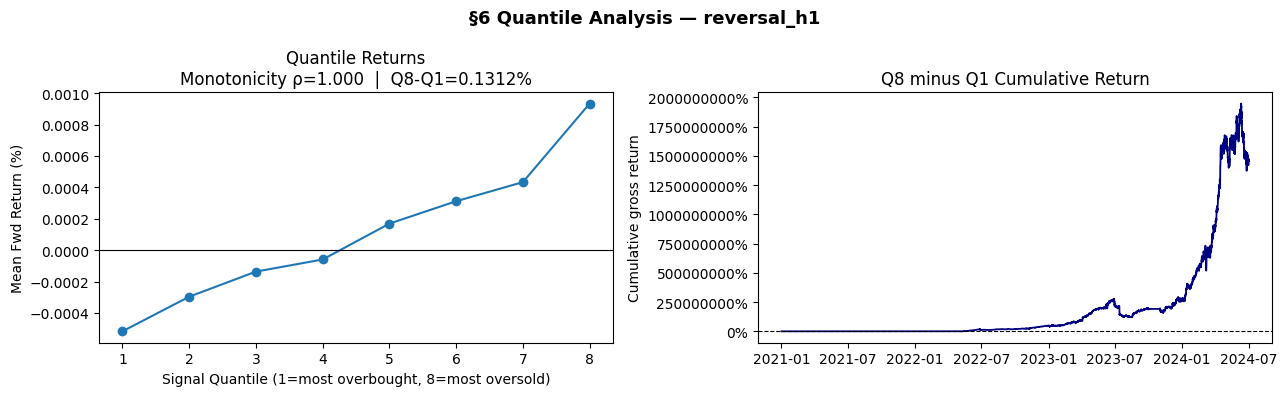

 quantile  mean_fwd_ret
        1       -0.0005
        2       -0.0003
        3       -0.0001
        4       -0.0001
        5        0.0002
        6        0.0003
        7        0.0004
        8        0.0009


In [10]:
n_quantiles = 8
q_means, spread_ts = quantile_analysis(
    signal_for_ic, 
    fwd_ret_for_ic,
    n_quantiles=n_quantiles,
    returns_are_log=settings["log_returns"],
)

# Quantile 1 is the lowest signal / most overbought bucket; quantile 8 is the
# highest signal / most oversold bucket. A good reversal signal should therefore
# have forward returns that increase from Q1 to Q8.
fwd_rets_vec = q_means.set_index("quantile")["mean_fwd_ret"]
mono_corr = fwd_rets_vec.corr(
    pd.Series(range(1, n_quantiles + 1), index=fwd_rets_vec.index),
    method="spearman",
)
top_minus_bottom = spread_ts.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"§6 Quantile Analysis — {selected_signal_label}", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(q_means["quantile"], q_means["mean_fwd_ret"], marker="o")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Signal Quantile (1=most overbought, {n_quantiles}=most oversold)")
ax.set_ylabel("Mean Fwd Return (%)")
ax.set_title(f"Quantile Returns\nMonotonicity ρ={mono_corr:.3f}  |  Q{n_quantiles}-Q1={top_minus_bottom*100:.4f}%")
ax.set_xticks(range(1, n_quantiles + 1))

ax = axes[1]
spread_cumulative = (1 + spread_ts.dropna()).cumprod()
ax.plot(spread_cumulative.index, spread_cumulative.values, color="navy", linewidth=1.3)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"Q{n_quantiles} minus Q1 Cumulative Return")
ax.set_ylabel("Cumulative gross return")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print(q_means.to_string(index=False))

## §7 Backtest

Equal-weight top/bottom quantile long/short portfolio, gross vs net after fees and half-spread. Short-horizon mean reversion should show a Sharpe that is positive but sensitive to costs (high turnover erodes the net edge), and long/short legs that are balanced with low net market beta. Cost sensitivity is stressed via `cost_stress_multipliers`.

**Conventions.** The book rebalances every `holding_period_bars` on the freshest signal (decimation is an IC-analysis device and no longer feeds the backtest). With `use_minute_execution`, entry and exit prices are real 1-minute closes `execution_delay_minutes` after the signal close — the old assumption of filling at the very close the signal was computed on is the delta=0 point. Rebalances are netted at a single print with costs on net turnover; weight drift within the hold is ignored (light backtest).


Minute execution: delta=1 min | direct 1,648,831 | LOCF fallback 57,700 | signal-close fallback 0 | unpriceable 0
Stale-fill exclusion ON: 57,700 fallback-filled cells removed from execution-priced returns


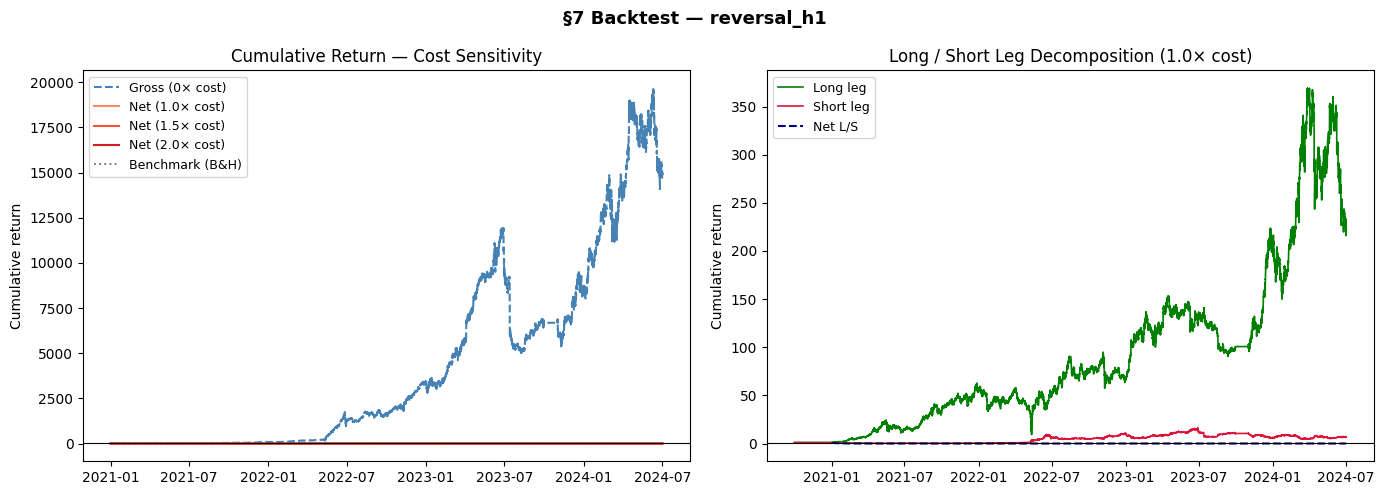


=== Backtest Metrics ===
                 sharpe_net  max_drawdown_net  mean_turnover  annualized_turnover  mean_cost_per_period  n_periods
cost_multiplier                                                                                                   
0.0000               3.6693           -0.5802         1.4862            6509.5152                0.0000      15253
1.0000             -27.4992           -1.0000         1.4862            6509.5152                0.0061      15253
1.5000             -42.6305           -1.0000         1.4862            6509.5152                0.0091      15253
2.0000             -57.2243           -1.0000         1.4862            6509.5152                0.0122      15253

Market correlation (net returns vs XBT/USD): -0.0041


In [11]:
# --- Execution-priced forward returns -----------------------------------------
# With minute execution, entry is the last real 1m close at-or-before
# close-time(t) + delta minutes and exit is H hours later at the same offset.
# The delay is embedded in the forward-return panel, so execution_delay_bars
# stays 0 (double-delay guard in load_research_settings).
_exec_close_cache, _exec_diag_cache = {}, {}

def _exec_close_panel(delta_minutes):
    """Fetch (once) and cache the execution close panel for a delay."""
    delta_minutes = int(delta_minutes)
    if delta_minutes not in _exec_close_cache:
        _closes_long = fetch_minute_exec_closes(
            engine,
            start_ts=close_wide.index.min(),
            end_ts=close_wide.index.max(),
            delay_minutes=delta_minutes,
            symbols=list(close_wide.columns),
        )
        panel, diags = build_execution_close_panel(
            _closes_long, close_wide.index, signal_close_wide=close_wide
        )
        _exec_close_cache[delta_minutes] = panel
        _exec_diag_cache[delta_minutes] = diags
    return _exec_close_cache[delta_minutes]

if settings["use_minute_execution"]:
    _delta_base = int(settings["execution_delay_minutes"])
    # Stale-fill exclusion: a P&L period requires real prints at both the
    # entry and exit fill — LOCF / signal-close fallback fills are prices at
    # which no trade happened (mostly thin out-of-universe names).
    fwd_ret_bt = compute_execution_forward_returns(
        _exec_close_panel(_delta_base),
        holding_period_bars=selected_holding_period,
        log_returns=settings["log_returns"],
        direct_fill_mask=_exec_diag_cache[_delta_base]["direct_fill_mask"],
    )
    _d = _exec_diag_cache[_delta_base]
    print(
        f"Minute execution: delta={_delta_base} min | direct {_d['n_direct']:,}"
        f" | LOCF fallback {_d['n_locf_fallback']:,}"
        f" | signal-close fallback {_d['n_signal_close_fallback']:,}"
        f" | unpriceable {_d['n_unpriceable']:,}"
    )
    print(
        f"Stale-fill exclusion ON: {_d['n_locf_fallback'] + _d['n_signal_close_fallback']:,} "
        f"fallback-filled cells removed from execution-priced returns"
    )
else:
    fwd_ret_bt = fwd_ret

base_1x_key = 1.0 if 1.0 in settings["cost_stress_multipliers"] else settings["cost_stress_multipliers"][-1]

cost_stress = settings["cost_stress_multipliers"]
backtest_results = {}

for mult in cost_stress:
    res = run_light_backtest(
        selected_signal_fresh,
        fwd_ret_bt,
        top_quantile=settings["top_quantile"],
        bottom_quantile=settings["bottom_quantile"],
        fee_bps=settings["fee_bps"] * mult,
        half_spread_bps=settings["half_spread_bps"] * mult,
        execution_delay_bars=settings["execution_delay_bars"],
        returns_are_log=settings["log_returns"],
        holding_period_bars=selected_holding_period,
    )
    backtest_results[mult] = res

base_1x = backtest_results[base_1x_key]

# Benchmark buy-and-hold curve normalised to strategy start
benchmark_col = settings["benchmark_symbol"]
benchmark_px  = (close_wide[benchmark_col]
                 if benchmark_col in close_wide.columns
                 else close_wide.mean(axis=1))
benchmark_curve = benchmark_px.loc[benchmark_px.index >= base_1x["cum_net"].index[0]].ffill()
benchmark_curve = benchmark_curve / benchmark_curve.dropna().iloc[0]

# Cumulative PnL plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"\u00a77 Backtest \u2014 {selected_signal_label}", fontsize=13, fontweight="bold")

ax = axes[0]
base = backtest_results[cost_stress[0]]
ax.plot(base["cum_gross"].index, base["cum_gross"].values,
        color="steelblue", linestyle="--", label="Gross (0\u00d7 cost)")
palette = plt.cm.Reds(np.linspace(0.4, 0.9, len(cost_stress)))
for mult, color in zip(cost_stress[1:], palette):
    res = backtest_results[mult]
    ax.plot(res["cum_net"].index, res["cum_net"].values,
            color=color, label=f"Net ({mult}\u00d7 cost)")
ax.plot(benchmark_curve.index, benchmark_curve.values,
        color="gray", linestyle=":", linewidth=1.4, label="Benchmark (B&H)")
ax.axhline(1, color="black", linewidth=0.8)
ax.set_title("Cumulative Return \u2014 Cost Sensitivity")
ax.set_ylabel("Cumulative return")
ax.legend(fontsize=9)

# Leg decomposition (base case)
ax = axes[1]
long_ret, short_ret = long_short_leg_returns(
    base_1x["weights"], fwd_ret_bt.reindex(base_1x["weights"].index),
    returns_are_log=settings["log_returns"],
)
cum_long  = (1 + long_ret.dropna()).cumprod()
cum_short = (1 + short_ret.dropna()).cumprod()
ax.plot(cum_long.index, cum_long.values,   color="green",  linewidth=1.2, label="Long leg")
ax.plot(cum_short.index, cum_short.values, color="crimson", linewidth=1.2, label="Short leg")
ax.plot(base_1x["cum_net"].index, base_1x["cum_net"].values,
        color="navy", linestyle="--", linewidth=1.5, label="Net L/S")
ax.axhline(1, color="black", linewidth=0.8)
ax.set_title(f"Long / Short Leg Decomposition ({base_1x_key}\u00d7 cost)")
ax.set_ylabel("Cumulative return")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Metrics summary
print("\n=== Backtest Metrics ===")
metrics_rows = []
for mult, res in backtest_results.items():
    m = res["metrics"].copy()
    m["cost_multiplier"] = mult
    metrics_rows.append(m)
metrics_df = pd.DataFrame(metrics_rows).set_index("cost_multiplier")
print(metrics_df[["sharpe_net", "max_drawdown_net", "mean_turnover",
                  "annualized_turnover", "mean_cost_per_period", "n_periods"]].to_string())

# Benchmark correlation
benchmark_fwd_log = fwd_ret[benchmark_col].reindex(base_1x["net_returns"].index)
if settings["log_returns"]:
    benchmark_fwd = np.exp(benchmark_fwd_log) - 1.0
else:
    benchmark_fwd = benchmark_fwd_log
beta = market_correlation(base_1x["net_returns"], benchmark_fwd)
print(f"\nMarket correlation (net returns vs {benchmark_col}): {beta:.4f}")


In [12]:
# --- Sanity check: delta=0 execution equals the stored hourly close -----------
# Both tables label bars at bar open, so with zero delay the last 1m close in
# [T, T+1h) must equal ohlcv's close at T on every hour the symbol actually
# traded. Any mismatch means the timestamp conventions have drifted.
if settings["use_minute_execution"]:
    _direct0 = (
        fetch_minute_exec_closes(
            engine,
            start_ts=close_wide.index.min(),
            end_ts=close_wide.index.max(),
            delay_minutes=0,
            symbols=list(close_wide.columns),
        )
        .pivot(index="bucket_ts", columns="symbol", values="exec_close")
        .reindex(index=close_wide.index, columns=close_wide.columns)
    )
    # Compare only real hourly bars (volume > 0): on rare occasions the raw
    # hourly dump is missing a bar that minute data has (e.g. XBT/USD
    # 2024-03-31 23:00) — there the hourly close is a synthetic forward-fill
    # and the 1m side is the more complete source, not an inconsistency.
    _hourly_real = (
        volume_wide.reindex(index=close_wide.index, columns=close_wide.columns) > 0
    )
    _cmp_mask = _direct0.notna() & _hourly_real
    _rel = ((_direct0 - close_wide).abs() / close_wide.abs()).where(_cmp_mask)
    _n_cells = int(_cmp_mask.sum().sum())
    _n_synth_with_1m = int((_direct0.notna() & ~_hourly_real).sum().sum())
    _max_rel = float(_rel.max().max())
    assert _max_rel < 1e-9, (
        f"delta=0 exec close != hourly close (max rel diff {_max_rel:.3e})"
    )
    print(
        f"delta=0 execution close matches the hourly close on {_n_cells:,} "
        f"real-trade cells (max rel diff {_max_rel:.3e}); "
        f"{_n_synth_with_1m:,} synthetic hourly bars had 1m trades (excluded)"
    )


delta=0 execution close matches the hourly close on 1,648,830 real-trade cells (max rel diff 0.000e+00); 1 synthetic hourly bars had 1m trades (excluded)


### Effective Spreads — Per-Asset Costs and the Bounce Floor

Two problems with a flat `half_spread_bps = 1` cost model: (i) it is roughly right for XBT/USD but off by an order of magnitude for the tail of the universe, and (ii) it says nothing about how much of the *gross* reversal P&L is mechanical bid-ask bounce. With spread *s*, close prints bounce between bid and ask, inducing a 1-lag autocovariance of about −s²/4 (Roll 1984) with **zero** mid-price reversion — apparent reversal profit that a taker cannot capture, because entering the position pays the same half-spread that generated it.

Below: per-asset Corwin–Schultz half-spread estimates from **hourly** high/low ranges (stale hours excluded; mean with negatives floored, per the paper). The estimation bar matters: crypto trades 24/7, so a daily range is pure volatility next to a 5–50 bps spread and the estimator comes out vol-dominated — on this dataset daily bars inflate XBT/USD to ≈30 bps half-spread vs ≈3 bps at hourly bars, in line with its real book. Then: the base backtest re-run with per-asset costs, and an order-of-magnitude **bounce floor** (`mean turnover × mean half-spread`) compared against the gross per-period return.


In [13]:
# --- Per-asset effective spreads (Corwin-Schultz, daily ranges) ----------------
half_spread_est, _cs_spread_panel = estimate_half_spread_bps_from_long(
    df_long, estimation_timeframe="1h", stat="mean"
)
half_spread_universe = (
    half_spread_est.reindex(close_wide.columns).dropna().sort_values()
)
print("=== Corwin-Schultz half-spread estimates (bps, mean over hourly bars) ===")
print(half_spread_universe.to_string(float_format=lambda x: f"{x:8.1f}"))
print(f"\nUniverse mean: {half_spread_universe.mean():.1f} bps | "
      f"flat assumption in config: {settings['half_spread_bps']:.1f} bps")

# --- Base backtest with per-asset spreads (same fee) ----------------------------
bt_flat = backtest_results[base_1x_key]
bt_asset = run_light_backtest(
    selected_signal_fresh,
    fwd_ret_bt,
    top_quantile=settings["top_quantile"],
    bottom_quantile=settings["bottom_quantile"],
    fee_bps=settings["fee_bps"],
    half_spread_bps=half_spread_est,
    execution_delay_bars=settings["execution_delay_bars"],
    returns_are_log=settings["log_returns"],
    holding_period_bars=selected_holding_period,
)
_cost_keys = ["sharpe_net", "mean_cost_per_period", "annualized_turnover"]
print("\n=== Cost model comparison (1x fee) ===")
print(pd.DataFrame({
    "flat_spread":      {k: bt_flat["metrics"][k] for k in _cost_keys},
    "per_asset_spread": {k: bt_asset["metrics"][k] for k in _cost_keys},
}).to_string())

# --- Bounce floor vs gross edge --------------------------------------------------
# If extreme-quantile membership were purely bounce-driven, the book earns about
# one half-spread per unit of turnover and gives it all back at execution. This
# is an order-of-magnitude floor, not an exact decomposition.
_gross_per_period = float(bt_flat["gross_returns"].mean())
_bounce_floor = float(
    bt_flat["metrics"]["mean_turnover"] * half_spread_universe.mean() * 1e-4
)
print(f"\nMean gross return per period : {_gross_per_period * 1e4:8.2f} bps")
print(f"Bounce floor (turnover x s/2): {_bounce_floor * 1e4:8.2f} bps")
if _bounce_floor > 0:
    print(f"Gross edge / bounce floor    : {_gross_per_period / _bounce_floor:8.2f}x")
if _gross_per_period <= _bounce_floor:
    print("-> The gross edge sits within the bid-ask bounce floor: consistent with "
          "bounce + stale prints rather than monetisable mid-price reversion.")
else:
    print("-> Gross edge exceeds the bounce floor: some mid-price reversion beyond "
          "pure bounce, but it must still clear fees + spread to trade.")


=== Corwin-Schultz half-spread estimates (bps, mean over hourly bars) ===
symbol
YFI/USD          8.4
TRX/USD          8.9
AXS/USD          8.9
LRC/USD          9.1
BAT/USD          9.4
DYDX/USD         9.7
XBT/USD          9.9
DASH/USD        10.0
SAND/USD        10.6
ETC/USD         10.6
ARB/USD         10.9
EOS/USD         10.9
ZEC/USD         11.3
WAVES/USD       11.4
ICP/USD         11.4
BCH/USD         11.6
OMG/USD         11.8
NEAR/USD        11.8
AKT/USD         11.9
ETH/USD         12.3
APE/USD         12.3
SNX/USD         12.8
XTZ/USD         12.8
XMR/USD         13.0
FLOW/USD        13.2
XLM/USD         13.2
FIL/USD         13.2
AAVE/USD        13.3
ENJ/USD         13.3
FTM/USD         13.3
INJ/USD         13.4
BLUR/USD        13.5
UNI/USD         13.6
KAVA/USD        13.7
AVAX/USD        13.9
SHIB/USD        13.9
STX/USD         14.1
LTC/USD         14.1
LDO/USD         14.3
XRP/USD         14.7
CRV/USD         14.9
MATIC/USD       15.1
GALA/USD        15.5
RNDR/USD        


=== Cost model comparison (1x fee) ===
                      flat_spread  per_asset_spread
sharpe_net               -27.4992          -37.7611
mean_cost_per_period       0.0061            0.0082
annualized_turnover     6509.5152         6509.5152

Mean gross return per period :     7.12 bps
Bounce floor (turnover x s/2):    21.46 bps
Gross edge / bounce floor    :     0.33x
-> The gross edge sits within the bid-ask bounce floor: consistent with bounce + stale prints rather than monetisable mid-price reversion.


## §8 Execution & Events

Stress-tests the §7 base-cost backtest for execution risks and regime dependence:

- **Rolling net Sharpe** over `rolling_window_bars` — shows performance stability over time
- **Execution delay** (minutes after the signal close, real 1m fills over `execution_delay_minutes_grid`) — mean-reversion signals decay rapidly; the delta=0 vs delta=1m gap quantifies the look-ahead of the old same-close fill assumption, and the 1-bar-shift anchor should sit near delta=60m
- **Vol-regime conditioning** — does the signal perform better in high-volatility environments, where price extremes are more likely to revert?

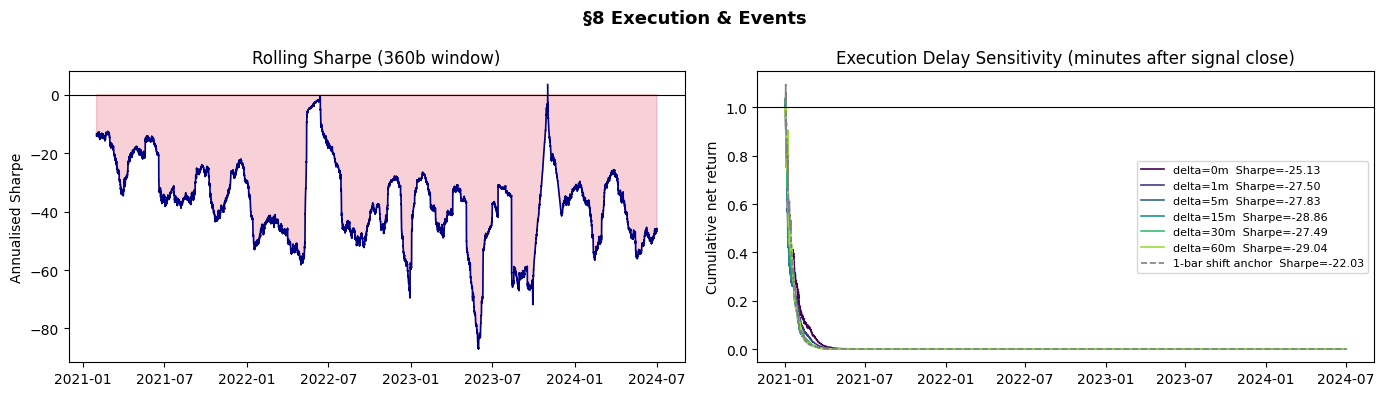

Net Sharpe by execution delay (minutes):
  delta=  0m : -25.13
  delta=  1m : -27.50
  delta=  5m : -27.83
  delta= 15m : -28.86
  delta= 30m : -27.49
  delta= 60m : -29.04
  Leakage quantified: Sharpe(delta=0) - Sharpe(delta=1m) = 2.36 (delta=0 fills at the very print the signal was computed on)

Mean net return — high vol regime (p99+): -0.4376%
Mean net return — low vol regime        : -0.5392%

High-vol minus low-vol mean net return: +0.1016%  →  supports the hypothesis that mean reversion is stronger during high-vol (extreme-move) regimes.


In [14]:
# --- Rolling Sharpe ----------------------------------------------------------
base_1x = backtest_results[base_1x_key]
ppy = base_1x["metrics"]["periods_per_year"]
rsh = rolling_sharpe(
    base_1x["net_returns"],
    window=settings["rolling_window_bars"],
    periods_per_year=ppy,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("§8 Execution & Events", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(rsh.index, rsh.values, color="navy", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8)
ax.fill_between(rsh.index, rsh.values, 0, where=(rsh > 0), alpha=0.2, color="green")
ax.fill_between(rsh.index, rsh.values, 0, where=(rsh < 0), alpha=0.2, color="crimson")
ax.set_title(f"Rolling Sharpe ({settings['rolling_window_bars']}b window)")
ax.set_ylabel("Annualised Sharpe")

# --- Execution delay sensitivity (minutes after the signal close) -------------
# Refines the old whole-bar delay sweep below one hour using real 1m fills.
# The 1-bar-shift anchor (weights shifted one signal bar, close-to-close
# returns) should sit close to the delta=60 point.
_bt_kwargs = dict(
    top_quantile=settings["top_quantile"],
    bottom_quantile=settings["bottom_quantile"],
    fee_bps=settings["fee_bps"],
    half_spread_bps=settings["half_spread_bps"],
    returns_are_log=settings["log_returns"],
    holding_period_bars=selected_holding_period,
)
delay_results = {}
anchor_bt = None
if settings["use_minute_execution"]:
    for _delta in settings["execution_delay_minutes_grid"]:
        _fwd_d = compute_execution_forward_returns(
            _exec_close_panel(_delta),
            holding_period_bars=selected_holding_period,
            log_returns=settings["log_returns"],
            direct_fill_mask=_exec_diag_cache[int(_delta)]["direct_fill_mask"],
        )
        delay_results[int(_delta)] = run_light_backtest(
            selected_signal_fresh, _fwd_d, execution_delay_bars=0, **_bt_kwargs
        )
    anchor_bt = run_light_backtest(
        selected_signal_fresh, fwd_ret, execution_delay_bars=1, **_bt_kwargs
    )
else:
    for delay in [0, 1]:
        delay_results[delay] = run_light_backtest(
            selected_signal_fresh, fwd_ret, execution_delay_bars=delay, **_bt_kwargs
        )

ax = axes[1]
if settings["use_minute_execution"]:
    _palette = plt.cm.viridis(np.linspace(0.0, 0.85, len(delay_results)))
    for (_delta, res), _color in zip(sorted(delay_results.items()), _palette):
        ax.plot(res["cum_net"].index, res["cum_net"].values, color=_color,
                linewidth=1.2,
                label=f"delta={_delta}m  Sharpe={res['metrics']['sharpe_net']:.2f}")
    ax.plot(anchor_bt["cum_net"].index, anchor_bt["cum_net"].values,
            color="gray", linestyle="--", linewidth=1.2,
            label=f"1-bar shift anchor  Sharpe={anchor_bt['metrics']['sharpe_net']:.2f}")
    ax.set_title("Execution Delay Sensitivity (minutes after signal close)")
else:
    for delay, res in delay_results.items():
        ax.plot(res["cum_net"].index, res["cum_net"].values, linewidth=1.2,
                label=f"delay={delay}b  Sharpe={res['metrics']['sharpe_net']:.2f}")
    ax.set_title("Execution Delay Sensitivity")
ax.axhline(1, color="black", linewidth=0.8)
ax.set_ylabel("Cumulative net return")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

if settings["use_minute_execution"]:
    print("Net Sharpe by execution delay (minutes):")
    for _delta, res in sorted(delay_results.items()):
        print(f"  delta={_delta:>3d}m : {res['metrics']['sharpe_net']:6.2f}")
    if 0 in delay_results and 1 in delay_results:
        _gap = (delay_results[0]["metrics"]["sharpe_net"]
                - delay_results[1]["metrics"]["sharpe_net"])
        print(
            f"  Leakage quantified: Sharpe(delta=0) - Sharpe(delta=1m) = {_gap:.2f}"
            f" (delta=0 fills at the very print the signal was computed on)"
        )

# --- Volatility-regime conditioning -----------------------------------------
# Identify high-vol bars using rolling realised vol of the benchmark. The
# quantile threshold is computed on the *full* sample (look-ahead) — this is
# a diagnostic of regime-conditional performance, not a tradable rule, and is
# consistent with the equivalent cell in the momentum notebook.
bench_ret = return_wide[settings["benchmark_symbol"]]
bench_vol = bench_ret.rolling(
    settings["rolling_window_bars"],
    min_periods=settings["rolling_window_bars"],
).std()
vol_q = bench_vol.quantile(settings["extreme_event_quantile"])
high_vol_mask = bench_vol >= vol_q

net_ret = base_1x["net_returns"]
mask_aligned = high_vol_mask.reindex(net_ret.index).fillna(False)
mean_ret_high_vol = net_ret[mask_aligned].mean()
mean_ret_low_vol  = net_ret[~mask_aligned].mean()

print(f"\nMean net return — high vol regime (p{settings['extreme_event_quantile']*100:.0f}+): "
      f"{mean_ret_high_vol*100:.4f}%")
print(f"Mean net return — low vol regime        : "
      f"{mean_ret_low_vol*100:.4f}%")
diff = mean_ret_high_vol - mean_ret_low_vol
direction = (
    "supports the hypothesis that mean reversion is stronger during high-vol "
    "(extreme-move) regimes"
    if diff > 0
    else "contradicts the high-vol-favours-reversion hypothesis on this sample — "
         "the signal performs *worse* in extreme regimes, suggesting trend / "
         "momentum dominates when volatility spikes"
)
print(f"\nHigh-vol minus low-vol mean net return: {diff*100:+.4f}%  →  {direction}.")

## §9 Robustness

Grid search over reversal lookback × holding period × cross-sectional transform × universe size. Each combination reports mean IC, NW-adjusted t-stat, net Sharpe, and train/test IC split. Results are sorted by mean IC; the heatmap below averages over nuisance parameters to show the lookback × holding surface.

Two additions make the grid read honestly: **selection-adjusted significance** (max-over-trials p-value for the best t-stat and a deflated Sharpe for the selected configuration) and **walk-forward evaluation with an embargo** (per-fold IC stability plus select-on-past/score-on-next-fold over the whole grid). See the subsection after the heatmap.

In [15]:
train_split = settings["train_split_date"]
_D_ic = int(settings["ic_rebalance_bars"])  # IC decimation only

# Identify feature family from the selected signal name (e.g. 'reversal' from 'reversal_h14').
_fam_m = re.match(r"^(.*?)(?:_h\d+)?$", selected_feature_name)
_family_prefix = _fam_m.group(1) if _fam_m else selected_feature_name


def _filter_universe(universe_input, top_n):
    if universe_input is None:
        return None
    return universe_input[universe_input["rank"] <= int(top_n)].copy()


def _train_test_stats(ic_ts, split_ts, nw_lag):
    train = ic_ts[ic_ts.index <= split_ts]
    test  = ic_ts[ic_ts.index >  split_ts]
    t_stats = ic_summary(train, nw_lag=nw_lag) if len(train) else None
    v_stats = ic_summary(test,  nw_lag=nw_lag) if len(test)  else None
    return {
        "train_mean_ic":   float(train.mean()) if len(train) else float("nan"),
        "test_mean_ic":    float(test.mean())  if len(test)  else float("nan"),
        "train_t_stat_nw": t_stats["t_stat_ic_nw"] if t_stats else float("nan"),
        "test_t_stat_nw":  v_stats["t_stat_ic_nw"] if v_stats else float("nan"),
    }


def _build_feature_for_lookback(cw, lookback, um):
    if "vol_adj" in _family_prefix:
        va = build_vol_adjusted_move(
            cw, [lookback],
            vol_window_bars=settings["vol_window_bars"],
            log_returns=settings["log_returns"],
        )
        key = "vol_adj_xsec_reversal" if "xsec" in _family_prefix else "vol_adj_reversal"
        raw = va[lookback][key]
    else:
        feat = build_return_reversal_features(
            cw, [lookback],
            log_returns=settings["log_returns"],
        )
        key = "xsec_reversal" if _family_prefix == "xsec_reversal" else "reversal"
        raw = feat[lookback][key]
    if um is not None:
        aligned_um = um.reindex(index=raw.index, columns=raw.columns).fillna(False)
        raw = raw.where(aligned_um)
    return raw


lookback_grid  = settings["momentum_lookback_grid_bars"]
holding_grid   = settings["holding_period_grid_bars"]
transform_grid = (
    settings["cross_sectional_transform_grid"]
    if apply_xsec_transform
    else [settings["cross_sectional_transform"]]
)
top_n_grid = settings["universe_top_n_grid"]

# Pre-compute forward returns for each unique holding period.
_fret_cache = {
    h: compute_forward_returns(close_wide, holding_period_bars=h, log_returns=settings["log_returns"])
    for h in holding_grid
}
# Backtest legs price at minute execution when enabled (same delta as §7);
# IC legs keep close-to-close returns (pure predictive power).
if settings["use_minute_execution"]:
    _delta_grid = int(settings["execution_delay_minutes"])
    _exec_panel_grid = _exec_close_panel(_delta_grid)
    _exec_mask_grid = _exec_diag_cache[_delta_grid]["direct_fill_mask"]
    _fret_bt_cache = {
        h: compute_execution_forward_returns(
            _exec_panel_grid, holding_period_bars=h,
            log_returns=settings["log_returns"],
            direct_fill_mask=_exec_mask_grid,
        )
        for h in holding_grid
    }
else:
    _fret_bt_cache = _fret_cache

total_combos = len(lookback_grid) * len(holding_grid) * len(transform_grid) * len(top_n_grid)
print(f"Running {total_combos} combinations  (feature family: {_family_prefix})...")

robust_rows = []
grid_ic_store, grid_nw_store = {}, {}  # per-combo IC series for walk-forward selection
for lookback in lookback_grid:
    for top_n in top_n_grid:
        u_df = _filter_universe(universe_df, top_n)
        um   = (
            build_monthly_universe_mask(close_wide.index, close_wide.columns, u_df)
            if u_df is not None else None
        )
        try:
            raw = _build_feature_for_lookback(close_wide, lookback, um)
        except Exception as exc:
            print(f"  SKIP (build) lookback={lookback} top_n={top_n}: {exc}")
            continue

        for holding in holding_grid:
            fret_base = _fret_cache[holding]
            fret_bt_base = _fret_bt_cache[holding]
            if um is not None:
                aligned_um = um.reindex(index=fret_base.index, columns=fret_base.columns).fillna(False)
                fret = fret_base.where(aligned_um)
                fret_bt = fret_bt_base.where(aligned_um)
            else:
                fret = fret_base
                fret_bt = fret_bt_base

            for transform in transform_grid:
                try:
                    sig_fresh = cross_sectional_rank_or_zscore(
                        raw,
                        method=transform,
                        min_assets_per_timestamp=settings["min_assets_per_timestamp"],
                    )
                    # IC on the decimated grid (sampling the fresh signal
                    # every _D_ic bars is identical to sampling the
                    # decimated one); backtests use the fresh signal with
                    # `holding` as the trading cadence.
                    if apply_rebalance_decimation_flag and _D_ic > 1:
                        sig_ic = sig_fresh.iloc[::_D_ic]
                        nw_g   = (max(int(holding), int(lookback)) - 1) // _D_ic
                    else:
                        sig_ic = sig_fresh
                        nw_g   = max(int(holding), int(lookback)) - 1
                    fret_ic = fret.reindex(sig_ic.index)

                    ic   = compute_ic_series(sig_ic, fret_ic, min_assets=settings["min_assets_per_timestamp"])
                    summ = ic_summary(ic, nw_lag=nw_g)
                    tt   = _train_test_stats(ic, train_split, nw_g)
                    _label = f"lb{lookback}_h{holding}_{transform}_top{top_n}"
                    grid_ic_store[_label] = ic
                    grid_nw_store[_label] = nw_g

                    bt = run_light_backtest(
                        sig_fresh, fret_bt,
                        top_quantile=settings["top_quantile"],
                        bottom_quantile=settings["bottom_quantile"],
                        fee_bps=settings["fee_bps"],
                        half_spread_bps=settings["half_spread_bps"],
                        execution_delay_bars=settings["execution_delay_bars"],
                        returns_are_log=settings["log_returns"],
                        holding_period_bars=holding,
                    )

                    robust_rows.append({
                        "lookback":            lookback,
                        "holding":             holding,
                        "transform":           transform,
                        "top_n":               top_n,
                        "nw_lag":              nw_g,
                        "mean_ic":             summ["mean_ic"],
                        "t_stat_ic":           summ["t_stat_ic"],
                        "t_stat_ic_nw":        summ["t_stat_ic_nw"],
                        "sharpe_net":          bt["metrics"]["sharpe_net"],
                        "mean_turnover":       bt["metrics"]["mean_turnover"],
                        "annualized_turnover": bt["metrics"]["annualized_turnover"],
                        "max_dd":              bt["metrics"]["max_drawdown_net"],
                        **tt,
                    })
                except Exception as exc:
                    print(f"  SKIP lookback={lookback} hold={holding} {transform} top_n={top_n}: {exc}")

robustness_df = (
    pd.DataFrame(robust_rows)
    .sort_values(["mean_ic", "sharpe_net"], ascending=False)
    .reset_index(drop=True)
)

display_cols = ["lookback", "holding", "transform", "top_n",
                "mean_ic", "t_stat_ic", "t_stat_ic_nw",
                "train_mean_ic", "test_mean_ic",
                "train_t_stat_nw", "test_t_stat_nw",
                "sharpe_net", "annualized_turnover", "max_dd"]
print(f"\n=== Robustness Grid \u2014 {_family_prefix} (top 20 by mean IC) ===")
print(robustness_df[display_cols].head(20).to_string(index=False))


Running 32 combinations  (feature family: reversal)...



=== Robustness Grid — reversal (top 20 by mean IC) ===
 lookback  holding transform  top_n  mean_ic  t_stat_ic  t_stat_ic_nw  train_mean_ic  test_mean_ic  train_t_stat_nw  test_t_stat_nw  sharpe_net  annualized_turnover  max_dd
        1        1      rank     10   0.0818    25.7826       25.7826         0.1017        0.0663          21.5796         15.4861    -46.0286           13011.1680 -1.0000
        1        1      rank     20   0.0810    30.4383       30.4383         0.0992        0.0668          27.8552         17.4389    -53.9423           13339.8645 -1.0000
        2        1      rank     20   0.0743    27.7171       27.7171         0.0862        0.0650          24.0680         16.8136    -40.5424            9733.8325 -1.0000
        2        1      rank     10   0.0740    23.1592       23.1592         0.0852        0.0653          18.1196         15.0218    -34.2314            9465.4700 -1.0000
        1        2      rank     10   0.0709    22.4820       22.4820         0

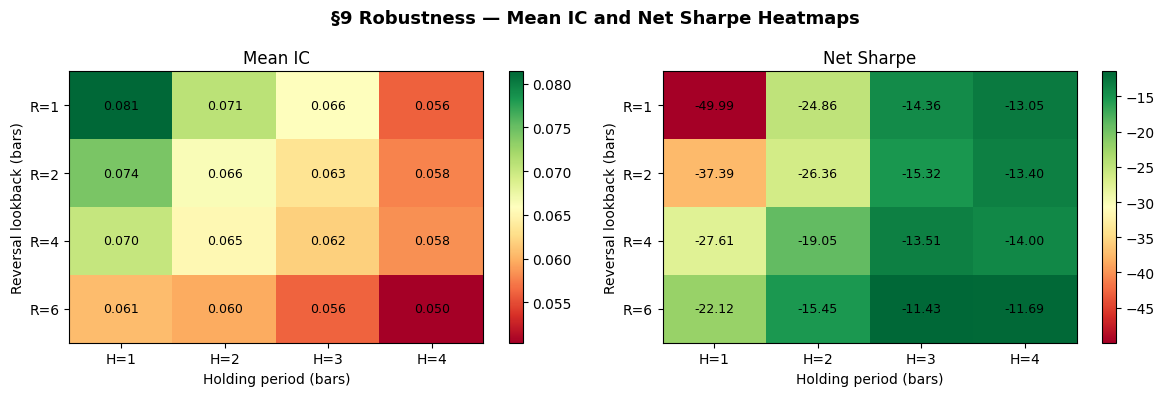

In [16]:
# Heatmap: mean IC by lookback × holding period (averaged over transform / top_n)
if not robustness_df.empty:
    pivot_ic = (
        robustness_df
        .groupby(["lookback", "holding"])["mean_ic"]
        .mean()
        .unstack("holding")
    )
    pivot_sharpe = (
        robustness_df
        .groupby(["lookback", "holding"])["sharpe_net"]
        .mean()
        .unstack("holding")
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("§9 Robustness — Mean IC and Net Sharpe Heatmaps",
                 fontsize=13, fontweight="bold")

    for ax, pivot, title, fmt in [
        (axes[0], pivot_ic,     "Mean IC",    "{:.3f}"),
        (axes[1], pivot_sharpe, "Net Sharpe", "{:.2f}"),
    ]:
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_yticks(range(len(pivot.index)))
        ax.set_xticklabels([f"H={c}" for c in pivot.columns])
        ax.set_yticklabels([f"R={r}" for r in pivot.index])
        ax.set_xlabel("Holding period (bars)")
        ax.set_ylabel("Reversal lookback (bars)")
        ax.set_title(title)
        plt.colorbar(im, ax=ax)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                ax.text(j, i, fmt.format(val), ha="center", va="center",
                        fontsize=9, color="black")

    plt.tight_layout()
    plt.show()

### Selection-Adjusted Significance & Walk-Forward

The grid above reports full-sample statistics for every combination — sorting it and quoting the winner is a **max-statistic**, not an unbiased estimate. Two corrections:

1. **Max-over-trials p-value** for the best NW t-stat: the honest null is the maximum of N trials, `1 − Φ(t)^N`. Trials are correlated, so the p-value is bracketed between the number of independent feature families and the total trial count. Alongside it, the **deflated Sharpe ratio** (Bailey–López de Prado) reports the probability that the selected configuration's true Sharpe exceeds the expected maximum of N no-skill trials — values near 0.5 mean the winner is indistinguishable from selection luck.
2. **Walk-forward with embargo**: per-fold IC of the selected signal over contiguous blocks (an embargo of the last overlapping lag separates folds so window overlap cannot leak), plus an honest grid evaluation that re-selects the best configuration on an expanding window of *past* observations and scores it on the next fold only. The pooled out-of-sample IC is what a fresh allocator following this process would actually have earned — unlike the single train/test split, which cannot distinguish regime change from decay and quietly recycles test data once a winner is quoted.


In [17]:
# --- 1) Selection-adjusted significance -----------------------------------------
n_feature_trials = len(ic_table)        # section 5 feature scan
n_grid_trials    = len(robustness_df)   # section 9 grid
_best_t = float(robustness_df["t_stat_ic_nw"].max())

# Trials are correlated -> bracket the p-value between "independent families"
# and "every trial independent".
_n_families = 9  # reversal, price-z, vol-adj, extreme, volume, vwap, rsi, range, xsec-z
for _n in [_n_families, n_feature_trials + n_grid_trials]:
    print(f"P(max of {_n:>3} null trials >= t={_best_t:.2f}) = "
          f"{max_over_trials_pvalue(_best_t, _n):.4f}")

# Deflated Sharpe of the selected configuration vs the grid's trial distribution
# (all Sharpes converted to per-period units before comparing).
_ppy_base = float(base_1x["metrics"]["periods_per_year"])
_bars_per_year = _ppy_base * selected_holding_period
_sr_period_rows = robustness_df["sharpe_net"] / np.sqrt(_bars_per_year / robustness_df["holding"])
_net = base_1x["net_returns"].dropna()
_dsr = deflated_sharpe_ratio(
    sharpe=float(base_1x["metrics"]["sharpe_net"]) / np.sqrt(_ppy_base),
    n_obs=len(_net),
    n_trials=n_grid_trials,
    var_sharpe=float(_sr_period_rows.var(ddof=1)),
    skew=float(_net.skew()),
    kurt=float(_net.kurt()) + 3.0,
)
print(f"\nDeflated Sharpe (selected config, {n_grid_trials} trials): "
      f"P(true SR > expected max of noise) = {_dsr['deflated_sharpe_prob']:.3f} "
      f"(expected max per-period SR under null: {_dsr['expected_max_sharpe']:.4f})")

# --- 2) Walk-forward with embargo -------------------------------------------------
_embargo = nw + 1  # last overlapping lag of the IC series, in its own (subsampled) units
wf_table = walk_forward_ic_table(ic_series, n_folds=5, embargo_obs=_embargo, nw_lag=nw)
print("\n=== Walk-forward IC (selected signal) ===")
print(wf_table.to_string())

wf_sel_table, wf_pooled = walk_forward_selection(
    grid_ic_store,
    n_folds=5,
    embargo_obs=max(grid_nw_store.values()) + 1,
    nw_lag_by_config=grid_nw_store,
)
print("\n=== Walk-forward grid selection (select on past, score on next fold) ===")
print(wf_sel_table.to_string())
print(f"\nPooled out-of-sample IC: mean={wf_pooled['mean_ic']:.4f}, "
      f"NW t={wf_pooled['t_stat_ic_nw']:.2f} (n={wf_pooled['n_obs']})")


P(max of   9 null trials >= t=30.44) = 0.0000
P(max of  77 null trials >= t=30.44) = 0.0000

Deflated Sharpe (selected config, 32 trials): P(true SR > expected max of noise) = 0.000 (expected max per-period SR under null: 0.1803)

=== Walk-forward IC (selected signal) ===
                         start                       end  n_obs  mean_ic  t_stat_ic_nw
fold                                                                                  
1    2021-01-01 00:00:00+00:00 2021-09-07 02:00:00+00:00   2987   0.0941       17.1628
2    2021-09-07 06:00:00+00:00 2022-05-14 02:00:00+00:00   2987   0.0736       14.4179
3    2022-05-14 06:00:00+00:00 2023-01-18 02:00:00+00:00   2987   0.0768       12.2318
4    2023-01-18 06:00:00+00:00 2023-09-24 04:00:00+00:00   2987   0.0677        9.5472
5    2023-09-24 08:00:00+00:00 2024-06-30 20:00:00+00:00   2987   0.0411        7.2439



=== Walk-forward grid selection (select on past, score on next fold) ===
        selected_config  selection_mean_ic  oos_mean_ic  oos_n_obs
fold                                                              
2     lb1_h1_rank_top10             0.1201       0.0800       2987
3     lb1_h1_rank_top10             0.1001       0.0776       2988
4     lb1_h1_rank_top10             0.0925       0.0791       2986
5     lb1_h1_rank_top20             0.0894       0.0471       2980

Pooled out-of-sample IC: mean=0.0709, NW t=21.04 (n=11941)


## §10 Interpretation

Use this checklist after running all cells to form a considered view on whether the signal is worth taking forward to a full backtest / live research pipeline.

### Signal Direction
- Raw short-term returns have **negative** mean IC — confirms a reversal pattern at the horizons tested.
- After negation, the core reversal signal has **positive** mean IC with a NW t-stat > 1.5 (ideally > 2).

### Best Feature Family
- Note which feature topped the IC table in §5.  Is it pure return reversal, or a vol-adjusted / VWAP variant?
- The `xsec_reversal` variant (cross-sectionally demeaned) should outperform raw reversal if the market is trending broadly.
- Volume-conditioned features (`vol_exhaustion`, `vol_blowoff`) add information only if volume data quality is high.

### Holding Period Sensitivity
- Mean-reversion signals typically peak at H=1 and decay rapidly — verify from the robustness heatmap.
- If H=2 shows similar IC to H=1, the signal is more persistent than typical crypto mean reversion.

### Cost Sensitivity
- Check the Sharpe gap between 0× and 1.5× cost in §7.  Short-horizon signals at 4h bars are inherently high-turnover.
- If the 1× cost Sharpe is well below the 0× Sharpe, the signal may only be exploitable with limit orders (lower effective spread).
- Execution delay (§8): Sharpe should decay smoothly from delta=1m to delta=60m. A large delta=0 vs delta=1m gap means headline numbers relied on unrealistic same-close fills; the delta=1m column is the honest headline.

### Vol-Regime Conditioning (§8)
- Does the signal perform better in high-vol regimes?  If yes, consider a regime-conditional version that
      scales position size by realised volatility.

### Comparison with Momentum (§5)
- Momentum features should have *opposite* sign IC at short horizons — this cross-validates both signals.
- At longer horizons (e.g. h=6 with 4h bars = 24h), momentum and reversion IC may converge — that is the typical
      crypto return autocorrelation pattern (short reversal, medium-term momentum).

### Train / Test (§9)
- Train IC and test IC should be in the same direction and of similar magnitude.  A large drop in test IC
      signals overfitting of the lookback / holding parameters.

### Selection-Adjusted Significance & Walk-Forward (§9)
- The max-over-trials p-value is the honest significance of the best grid row; if it is unremarkable, the winner is a selection effect regardless of its raw t-stat.
- Per-fold walk-forward IC should be same-sign and of similar magnitude across folds; the pooled select-on-past/score-on-next IC is what a fresh allocator would actually have earned.
- Stale-print artifact (§5): the tradable hypothesis is only the *masked* reversal IC; the delta to the unmasked IC is a data artifact, not alpha. The bounce floor (§7) then bounds how much of the gross P&L a taker could never capture.